https://www.kaggle.com/datasets/ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning

In [ ]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [ ]:
# Import the 'drive' module from 'google.colab' which allows Colab to access Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# We define the file path to the CSV dataset stored in Google Drive
file_path = '/content/drive/MyDrive/datasets/retail_data.csv'

# We read the CSV file from the specified path into a pandas DataFrame called 'retail_data'
retail_data = pd.read_csv(file_path)

In [ ]:
# explore dataset
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
retail_data.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
# rename column
retail_data.columns = retail_data.columns.str.lower().str.replace(' ','_')


# Another way to rename columns
#retail_data = retail_data.rename(columns={'Transaction ID':'transaction_id',
                                          # 'Customer ID':'customer_id',
                                          # 'Category':'category',
                                          # 'Item':'item', 'Price Per Unit':'price_per_unit',
                                          # 'Quantity':'quantity','Total Spent':'total_spent',
                                          # 'Payment Method':'payment_method','Location':'location',
                                          # 'Transaction Date':'transaction_date','Discount Applied':'discount_applied'
#}

#)


In [ ]:
# check if columns are renamed
retail_data.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

In [ ]:
# check duplicated rows
retail_data.duplicated().sum()

# no duplicated rows

np.int64(0)

In [ ]:
# check missing values
retail_data.isna().mean()*100

# we have 5 columns with missing values

,0
transaction_id,0.000000
customer_id,0.000000
category,0.000000
item,9.646123
price_per_unit,4.842942
quantity,4.803181
total_spent,4.803181
payment_method,0.000000
location,0.000000
transaction_date,0.000000


In [ ]:
# check item unique values
print(retail_data['item'].nunique())
print(retail_data['item'].mode())

# we fill missing value with 'Unknown'
# keep the data object

200
0    Item_2_BEV
Name: item, dtype: object


In [ ]:
# Fill 'item' missing values with 'Unknown'
retail_data["item"] = retail_data["item"].fillna("Unknown")

In [ ]:
# we find relationship to fill the missing values between 'price_per_unit','quantity','total_spent'
print(retail_data[['price_per_unit','quantity','total_spent']].sample(60))

# dealing with missing values for these columns:
# total spent = sum of price_per_unit * quantity
# price_per_unit = total_spent / quantity
# quantity = total_spent/ price_per_unit
# otherwise, fill with median
# keep data type float64

       price_per_unit  quantity  total_spent
9649              6.5       8.0         52.0
9114             29.0      10.0        290.0
9170              8.0       5.0         40.0
10624             6.5       3.0         19.5
9135              NaN       3.0         91.5
11355            29.0      10.0        290.0
4141             14.0       1.0         14.0
80               29.0      10.0        290.0
8882             41.0       4.0        164.0
3537             17.0       9.0        153.0
6155             36.5       1.0         36.5
6558             15.5       2.0         31.0
1978              5.0       9.0         45.0
11999            41.0       2.0         82.0
6137              6.5       6.0         39.0
2292              NaN       4.0        146.0
1930              6.5       4.0         26.0
10279            21.5       8.0        172.0
7045             11.0       5.0         55.0
2280             11.0       5.0         55.0
1072             23.0       9.0        207.0
8453      

In [ ]:
# fill missing values in total_spent
# Creates a Boolean Series (True/False) indicating missing values in the 'total_spent' column
mask = retail_data['total_spent'].isna()

retail_data.loc[mask, 'total_spent'] = (
    retail_data.loc[mask, 'price_per_unit'] *
    retail_data.loc[mask, 'quantity']
)

In [ ]:
# fill missing values in price_per_unit
mask = retail_data['price_per_unit'].isna()

retail_data.loc[mask, 'price_per_unit'] = (
    retail_data.loc[mask, 'total_spent'] /
    retail_data.loc[mask, 'quantity']
)

In [ ]:
# fill missing values in quantity
mask = retail_data['quantity'].isna()

retail_data.loc[mask, 'quantity'] = (
    retail_data.loc[mask, 'total_spent'] /
    retail_data.loc[mask, 'price_per_unit']
)

In [ ]:
# fill remaining missing values with medians
retail_data['price_per_unit'] = retail_data['price_per_unit'].fillna(
    retail_data['price_per_unit'].median()
)

retail_data['quantity'] = retail_data['quantity'].fillna(
    retail_data['quantity'].median()
)

retail_data['total_spent'] = retail_data['total_spent'].fillna(
    retail_data['total_spent'].median()
)

In [ ]:
# check unique values of 'discount_applied'
retail_data['discount_applied'].unique()
retail_data['discount_applied'].value_counts(dropna=False)

# missing values is 4199 which is very large
# convert data type into boolean and keep NAN

,count
discount_applied,
True,4219
NaN,4199
False,4157


In [ ]:
# convert 'discount_applied' into boolean and keep na values, because they are third of the data
retail_data['discount_applied'] = retail_data['discount_applied'].astype('boolean')

In [ ]:
# check again missing values
retail_data.isna().mean()*100

,0
transaction_id,0.00000
customer_id,0.00000
category,0.00000
item,0.00000
price_per_unit,0.00000
quantity,0.00000
total_spent,0.00000
payment_method,0.00000
location,0.00000
transaction_date,0.00000


In [ ]:
# check structure of data for data conversion if needed!
retail_data.info()

# we convert from object to category the following columns:
# 'category', payment_method', 'location'
# we convert 'transaction_date' into datatime data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    12575 non-null  object 
 1   customer_id       12575 non-null  object 
 2   category          12575 non-null  object 
 3   item              12575 non-null  object 
 4   price_per_unit    12575 non-null  float64
 5   quantity          12575 non-null  float64
 6   total_spent       12575 non-null  float64
 7   payment_method    12575 non-null  object 
 8   location          12575 non-null  object 
 9   transaction_date  12575 non-null  object 
 10  discount_applied  8376 non-null   boolean
dtypes: boolean(1), float64(3), object(7)
memory usage: 1007.1+ KB


In [ ]:
# convert 'category', payment_method', 'location' from object to category the following columns:
category_columns = ['category','payment_method','location']
for col in category_columns:
  retail_data[col] = retail_data[col].astype('category')

In [ ]:
# convert 'transaction_date' into datatime data type
retail_data['transaction_date'] = pd.to_datetime(retail_data['transaction_date'], errors='coerce')

In [ ]:
# check data structure
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  category      
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  float64       
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  category      
 8   location          12575 non-null  category      
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  8376 non-null   boolean       
dtypes: boolean(1), category(3), datetime64[ns](1), float64(3), object(3)
memory usage: 749.8+ KB


In [ ]:
# feature engineering from 'transaction_date'
retail_data['year'] = retail_data['transaction_date'].dt.year
retail_data['quarter'] = retail_data['transaction_date'].dt.quarter
retail_data['month'] = retail_data['transaction_date'].dt.month
retail_data['month_name'] = retail_data['transaction_date'].dt.month_name()
retail_data['day_of_week'] = retail_data['transaction_date'].dt.dayofweek
retail_data['day'] = retail_data['transaction_date'].dt.day
retail_data['day_name'] = retail_data['transaction_date'].dt.day_name()

In [ ]:
# check data structure
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  category      
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  float64       
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  category      
 8   location          12575 non-null  category      
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  8376 non-null   boolean       
 11  year              12575 non-null  int32         
 12  quarter           12575 non-null  int32         
 13  month             12575 non-null  int32         
 14  month_name        1257

In [ ]:
retail_data.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,year,quarter,month,month_name,day_of_week,day,day_name
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,2,4,April,0,8,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,3,7,July,6,23,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,4,10,October,2,5,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,<NA>,2022,2,5,May,5,7,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,4,10,October,6,2,Sunday


**Exploratory Data Analysis** '**EDA**'

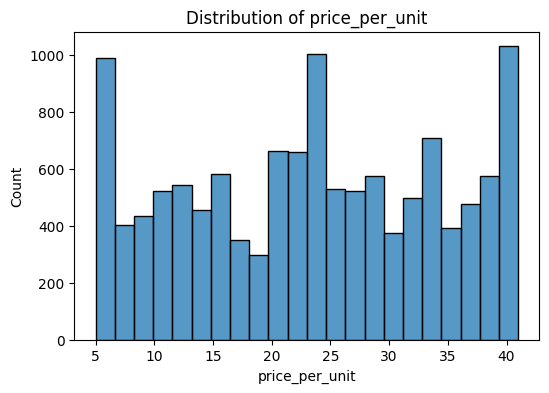

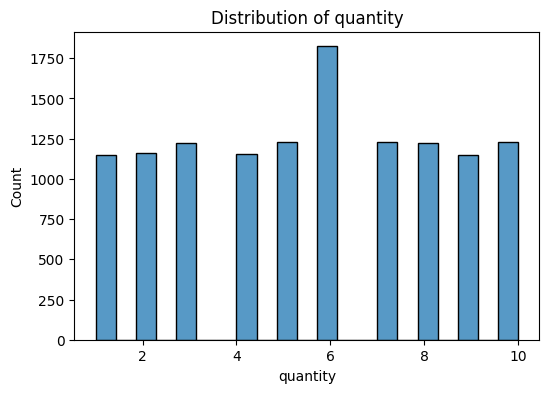

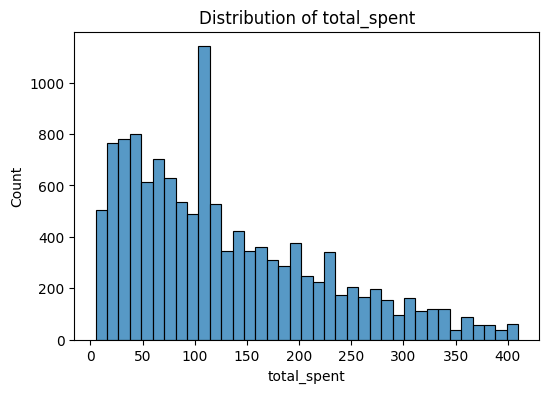

In [ ]:
# How are sales distributed overall?

sales = ['price_per_unit', 'quantity', 'total_spent']
for col in sales:
  plt.figure(figsize=(6,4))
  sns.histplot(data = retail_data, x= col)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

In [ ]:
# Which product categories generate the most revenue?
retail_data.groupby('category')['total_spent'].sum().sort_values(ascending=False)

# Butchers category generate the most revenue

/tmp/ipykernel_1075/544122695.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retail_data.groupby('category')['total_spent'].sum().sort_values(ascending=False)


,total_spent
category,
Butchers,215930.0
Electric household essentials,211951.0
Beverages,204751.0
Food,203600.5
Furniture,202471.0
Computers and electric accessories,199481.0
Patisserie,191605.0
Milk Products,187815.5


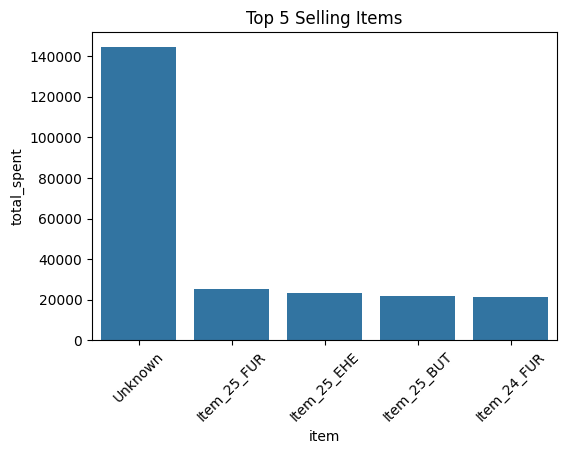

In [ ]:
# Which individual items sell the most?
most_selling_items= (
    retail_data.groupby('item')['total_spent']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(x='item', y= 'total_spent', data= most_selling_items)
plt.title('Top 5 Selling Items')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Who are the highest-value customers?
customer_summary= (
    retail_data.groupby('customer_id')
    .agg(
        total_purchase=('total_spent','sum'),
        first_purchase=('transaction_date', 'min'),
        last_purchase=('transaction_date', 'max'),
        avg_order_value=('total_spent','mean'),
        max_purchase=('total_spent','max'),
        min_purchase=('total_spent','min')
    )
    .sort_values('total_purchase',ascending=False)
    .head(5)
    .reset_index()
)

print(customer_summary)

  customer_id  total_purchase first_purchase last_purchase  avg_order_value  \
0     CUST_24         71056.0     2022-01-01    2025-01-18       130.858195   
1     CUST_08         70172.5     2022-01-03    2025-01-17       131.655722   
2     CUST_05         70012.5     2022-01-03    2025-01-14       128.699449   
3     CUST_23         67979.0     2022-01-02    2025-01-15       132.512671   
4     CUST_13         67858.0     2022-01-04    2025-01-18       127.074906   

   max_purchase  min_purchase  
0         410.0           5.0  
1         410.0           5.0  
2         410.0           5.0  
3         410.0           5.0  
4         410.0           5.0  


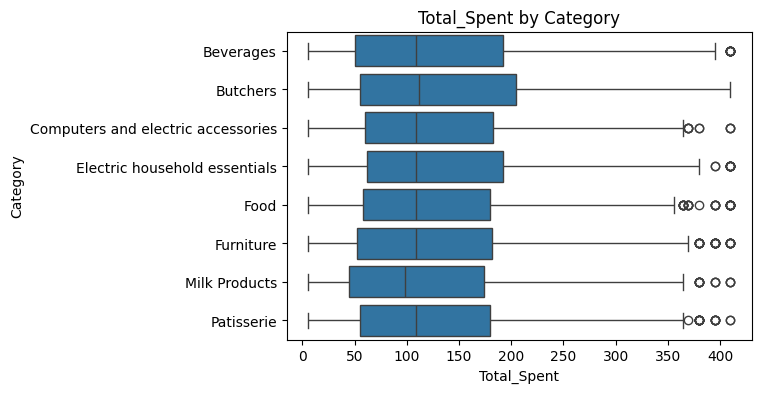

In [ ]:
# what is the distribution of total_spent across different product categories.
plt.figure(figsize=(6,4))
sns.boxplot(x= 'total_spent', y= 'category', data = retail_data)
plt.title('Total_Spent by Category')
plt.xlabel('Total_Spent')
plt.ylabel('Category')
plt.show()

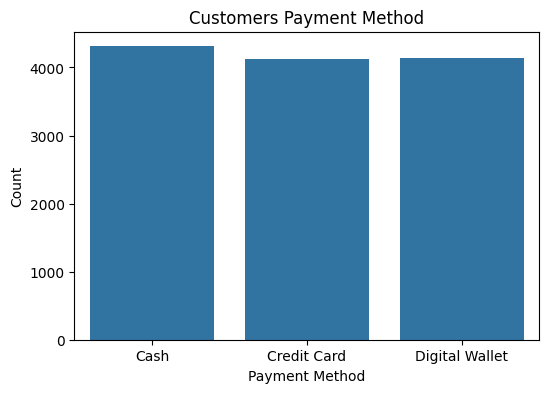

In [ ]:
# Which payment methods are most popular?
plt.figure(figsize=(6,4))
sns.countplot(x= 'payment_method',data= retail_data)
plt.title('Customers Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

# Customers prefer to pay in cash.

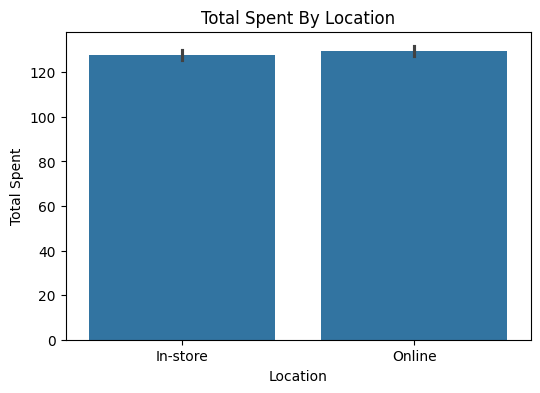

In [ ]:
# Which locations generate the highest revenue?

plt.figure(figsize=(6,4))
sns.barplot(x= 'location', y = 'total_spent',data= retail_data)
plt.title('Total Spent By Location')
plt.xlabel('Location')
plt.ylabel('Total Spent')
plt.show()

# Online location generates a slightly higher revenue!

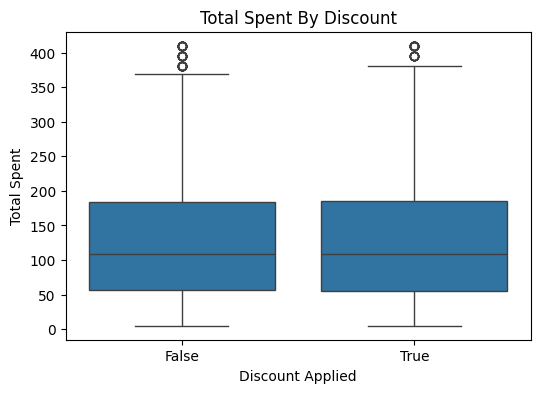

In [ ]:
# Do discounts increase spending?
plot_data = retail_data.dropna(subset=['discount_applied', 'total_spent'])

plt.figure(figsize=(6,4))
sns.boxplot(x='discount_applied', y='total_spent', data=plot_data)

plt.title('Total Spent By Discount')
plt.xlabel('Discount Applied')
plt.ylabel('Total Spent')
plt.show()

# No clear evidence that discounts increase total spending.

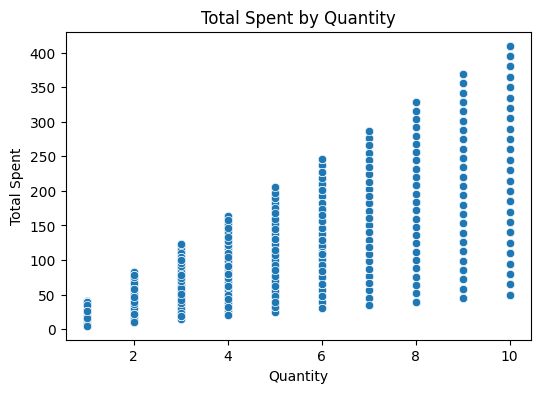

In [ ]:
# How does quantity purchased relate to total spending?

plt.figure(figsize=(6,4))
sns.scatterplot(x='quantity', y='total_spent', data=plot_data)
plt.title('Total Spent by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

# As quantity increases from 1 to 10, total spent also increases.
# That suggests a strong positive correlation.

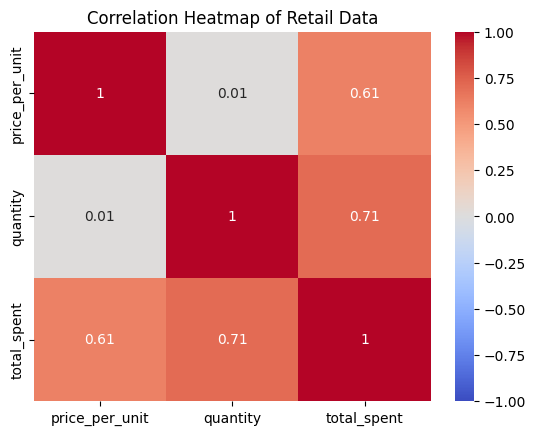

In [ ]:
# How are numeric variables ['price_per_unit' 'quantity' 'total_spent'] related?
df_corr= retail_data[['price_per_unit','quantity','total_spent']].corr()
sns.heatmap(data= df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap of Retail Data")
plt.show()

# total spent is positively correlated with quantity and price per unit

**Time-Based Trends Questions**

In [ ]:
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  category      
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  float64       
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  category      
 8   location          12575 non-null  category      
 9   transaction_date  12575 non-null  datetime64[ns]
 10  discount_applied  8376 non-null   boolean       
 11  year              12575 non-null  int32         
 12  quarter           12575 non-null  int32         
 13  month             12575 non-null  int32         
 14  month_name        1257

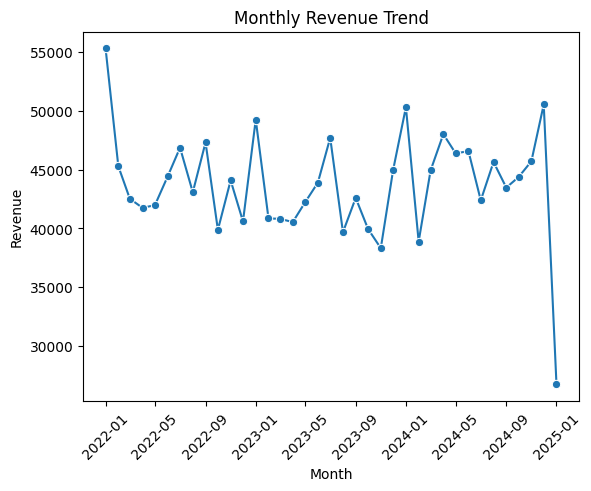

In [ ]:
monthly_sales = retail_data.groupby(['year', 'month']).agg(
    total_revenue=('total_spent', 'sum')
).reset_index()

monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' +
    monthly_sales['month'].astype(str)
)

sns.lineplot(
    data=monthly_sales,
    x='year_month',
    y='total_revenue',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()